In [182]:
import decoupler as dc
from scipy.stats import rankdata
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
from scipy.sparse import csr_matrix, issparse
from scipy import sparse
from tqdm.auto import tqdm
from scipy.special import ndtr
import warnings

warnings.filterwarnings("ignore")

In [183]:
# Generate simulated data
!uv run simulated_data_generator.py simulated_data_parameters.json

{'output_dir': 'simulated_data/', 'output_exp_file': 'simulated_scRNASeq_data.tsv', 'output_prior_file': 'simulated_prior_data.tsv', 'output_ground_truth_file': 'simulated_ground_truth.tsv', 'n_cells': 1000, 'n_genes': 1000, 'n_tfs': 50, 'n_clusters': 5, 'missing_percentage': 80, 'weighted': False, 'random_seed': 42, 'tf_effect_factor': 1.75}
Generating gene expression data...
Zero percentage before explicit dropout: 51.27%
Target zero percentage: 80.00%
Zero percentage after dropout: 80.00%
Wrote prior to simulated_prior_data.tsv
Wrote ground truth to simulated_ground_truth.tsv
Wrote gene expression to simulated_scRNASeq_data.tsv


In [184]:
# Gene Expression data
raw = pd.read_csv("simulated_data/simulated_scRNASeq_data.tsv", sep="\t", index_col=0)

# Calculate zero percentage
zero_percentage = (raw == 0).sum().sum() / raw.size * 100
print(f"Zero percentage in the gene expression data: {zero_percentage:.2f}%")

adata = sc.AnnData(csr_matrix(raw.values), var=pd.DataFrame(index=raw.columns), obs=pd.DataFrame(index=raw.index))
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Zero percentage in the gene expression data: 80.00%


In [185]:
# Prior Knowledge Network
net_file = "simulated_data/simulated_prior_data.tsv"
effect_map = {"upregulates-expression": 1, "downregulates-expression": -1}
net = pd.read_csv(net_file, sep="\t", converters={"interaction": effect_map.get}, )

In [186]:
ground_truth_df = pd.read_csv("simulated_data/simulated_ground_truth.tsv", sep="\t", index_col=0)

In [187]:
!uv run z-aggregate --dataset simulated_data/simulated_scRNASeq_data.tsv --prior-type simulated_data/simulated_prior_data.tsv --output results --verbose --min-targets 4 --weight-type Uniform --preprocess --min-genes 1 --min-cells 1 

2026-03-17 10:45:12 | [INFO] Reading expression data from: simulated_data/simulated_scRNASeq_data.tsv
2026-03-17 10:45:12 | [INFO]    Loaded data shape: 1000 cells x 1000 genes
2026-03-17 10:45:12 | [INFO] Starting Preprocessing...
2026-03-17 10:45:12 | [INFO]    Filtered cells (min_genes=1): Removed 0 cells.
2026-03-17 10:45:12 | [INFO]    Filtered genes (min_cells=1): Removed 22 genes.
2026-03-17 10:45:12 | [INFO]    Mitochondrial filter (<20.0%): Removed 0 cells.
2026-03-17 10:45:12 | [INFO] Preprocessing complete. Final shape: 1000 cells x 978 genes
2026-03-17 10:45:12 | [INFO] Reading prior network for type: simulated_data/simulated_prior_data.tsv
2026-03-17 10:45:12 | [INFO] Reading custom prior network from file: simulated_data/simulated_prior_data.tsv
/Users/kisanthapa/MajorFiles/Research/Kale Research/z-aggregate/src/preprocessing.py:154: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

In [188]:
z_aggregate_score_df = pd.read_csv(
    "results/simulated_scRNASeq_data_simulated_prior_data_z_agg_scores.tsv",
    sep="\t",
    index_col=0,
)

z_aggregate_score_df = z_aggregate_score_df.loc[adata.obs_names]
adata.obsm["score_z-agg"] = z_aggregate_score_df

In [189]:
z_aggregate_score_df

,TF_1,TF_10,TF_12,TF_13,TF_17,TF_18,TF_19,TF_2,TF_20,TF_21,...,TF_43,TF_44,TF_47,TF_48,TF_5,TF_50,TF_6,TF_7,TF_8,TF_9
Cell_1,0.182653,-0.414065,-0.151509,-1.209305,-0.813787,-0.600859,-0.517863,-0.491494,8.484715,-0.149552,...,-1.081868,0.265570,0.092908,-0.468662,-0.979592,0.283096,-1.824013,4.783490,0.130464,0.028135
Cell_2,-0.729925,0.476638,-0.117884,0.032506,-1.666583,0.213569,-0.498104,-1.256216,-0.572514,0.116375,...,0.182984,-0.403426,1.399873,-1.187321,-1.319809,-0.819277,-1.158058,1.730413,-0.486475,-2.522946
Cell_3,-0.523968,4.745074,11.115525,7.080013,3.542484,0.686731,0.775597,5.024791,1.021303,3.785078,...,-0.175738,2.327703,1.876942,1.182223,1.491303,2.439340,2.077796,0.074724,-0.344224,1.339791
Cell_4,-0.408914,3.868037,0.837012,1.447895,0.525016,0.051917,-0.531731,-0.800363,2.083724,1.230270,...,-0.050766,1.376918,-0.865034,-1.196683,-0.753705,-0.882032,-0.464940,-0.539039,-0.120138,2.322688
Cell_5,0.339901,0.188193,0.523264,-0.027885,0.472004,1.726979,0.865275,-1.256216,-0.451785,-0.953888,...,2.878691,-0.207537,0.464751,0.857388,1.679091,0.511378,0.057918,-2.048274,-0.254076,0.691923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cell_996,-0.080563,-2.049495,1.868372,-0.574576,-0.085007,4.408380,-0.341174,-1.256216,0.747899,-0.787230,...,-0.609901,-0.769546,0.619684,0.174024,0.318050,0.563163,0.092301,0.202625,3.203983,-2.148906
Cell_997,1.967897,-0.252297,0.060119,0.107158,0.508085,1.548832,0.004027,1.219757,1.665141,-0.248901,...,0.536868,3.138256,-0.679529,1.059539,0.030030,3.233418,0.235013,-0.404214,-1.180843,3.215819
Cell_998,0.548970,-0.387968,0.352903,-1.209305,-1.499589,-1.070995,-1.514392,0.176050,-0.069537,0.148912,...,0.123246,-0.554178,-0.032107,0.030615,-0.197439,2.910272,-1.508678,0.120790,-0.636801,-0.848265
Cell_999,-0.966917,0.979020,-1.177584,1.824579,-1.460347,-0.161768,-0.772643,-1.256216,-1.041278,-1.291334,...,-0.474057,-0.793942,-0.285433,0.400228,0.078141,-1.490011,-2.438098,-0.216370,-1.093324,-1.623050


In [190]:
# Make network decoupler compatible
net_dc = net.copy()
net_dc["weight"] = net_dc["interaction"] * net_dc["weight"]
net_dc = net_dc[["source", "target", "weight"]]

In [191]:
dc.mt.ulm(adata, net_dc, tmin=0)
# dc.mt.mlm(adata, net_dc, tmin=0)
# dc.mt.zscore(adata, net_dc, tmin=0)

In [192]:
sc.pp.scale(adata)
dc.mt.viper(adata, net_dc, tmin=0)

## Plot ROC Curves

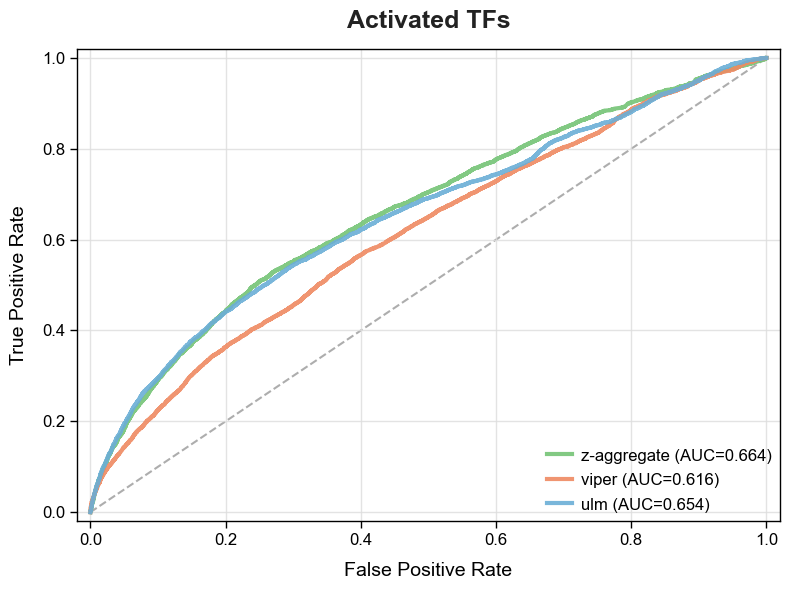

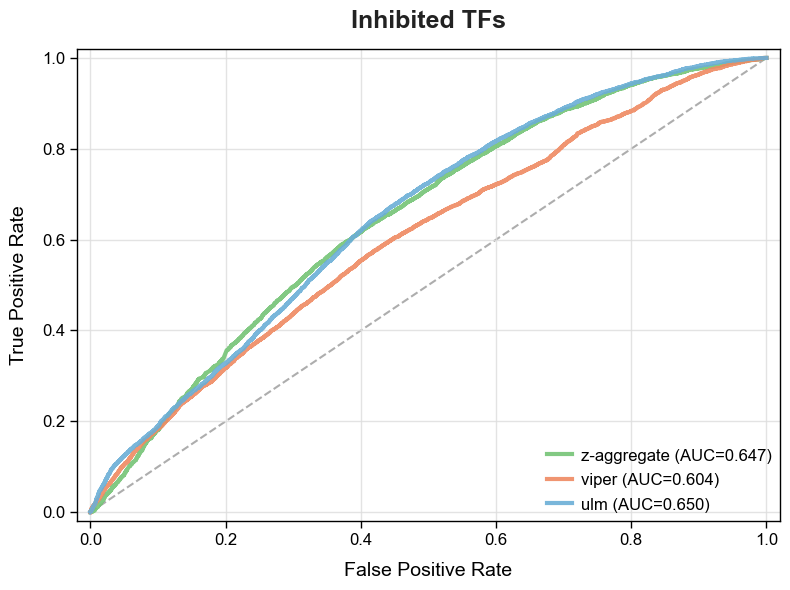

In [193]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import os

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

def plot_custom_benchmarks_paper(adata, ground_truth_df, methods_dict,
                                 text_size=16, filename_prefix=None):
    color_map = {
        "z-aggregate": "#74c476",  # Soft Green
        "ulm": "#6baed6",          # Soft Blue
        "viper": "#ef8a62",        # Salmon/Orange
        "mlm": "#9e9ac8",          # Purple
        "zscore": "#969696"        # Grey
    }

    fallback_palette = sns.color_palette("colorblind", n_colors=10)

    # Define the two tasks
    tasks = [
        {
            "title": "Activated TFs",
            "gt_val": 1,
            "invert_score": False,
            "suffix": "activated"
        },
        {
            "title": "Inhibited TFs",
            "gt_val": -1,
            "invert_score": True,
            "suffix": "inhibited"
        }
    ]

    for task in tasks:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

        # --- Collect Data ---
        roc_data = []
        has_data = False

        for method_name, obsm_key in methods_dict.items():
            if obsm_key not in adata.obsm:
                continue

            scores_df = adata.obsm[obsm_key]
            common_tfs = list(set(ground_truth_df.columns) & set(scores_df.columns))
            common_cells = list(set(ground_truth_df.index) & set(scores_df.index))

            if not common_tfs or not common_cells:
                continue

            # Data prep
            y_true_flat = ground_truth_df.loc[common_cells, common_tfs].values.flatten()
            y_score_flat = scores_df.loc[common_cells, common_tfs].values.flatten()

            # Determine positive class based on task
            if task["gt_val"] == 1:
                y_true_binary = (y_true_flat == 1).astype(int)
            else:
                y_true_binary = (y_true_flat == -1).astype(int)

            if y_true_binary.sum() == 0:
                continue

            has_data = True

            if task["invert_score"]:
                y_score_flat = -y_score_flat

            fpr, tpr, _ = roc_curve(y_true_binary, y_score_flat)
            roc_val = auc(fpr, tpr)

            roc_data.append({
                "name": method_name,
                "fpr": fpr,
                "tpr": tpr,
                "auc": roc_val
            })

        if not has_data:
            plt.close(fig)
            print(f"Skipping {task['title']} - No valid ground truth data found.")
            continue
        # 1. Diagonal random chance line
        ax.plot([0, 1], [0, 1], color='#999999', linestyle='--', lw=1.5, alpha=0.8, zorder=1)

        # 2. Plot Methods
        for i, data in enumerate(roc_data):
            # Determine Color
            c = None
            for key, val in color_map.items():
                if key in data["name"].lower():
                    c = val
                    break
            if c is None:
                c = fallback_palette[i % len(fallback_palette)]

            ax.plot(
                data["fpr"], data["tpr"],
                label=f'{data["name"]} (AUC={data["auc"]:.3f})',
                color=c,
                lw=3.0,
                alpha=0.9,
                zorder=2
            )

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])

        # Bold/Large Title
        ax.set_title(task["title"], fontsize=text_size + 4, fontweight='bold', pad=15, color='#222222')

        # Labels
        ax.set_xlabel('False Positive Rate', fontsize=text_size, labelpad=10)
        ax.set_ylabel('True Positive Rate', fontsize=text_size, labelpad=10)
        ax.tick_params(axis='both', which='major', labelsize=text_size - 2, width=1, length=5)

        ax.legend(
            loc="lower right",
            fontsize=text_size - 2,
            frameon=False,
            handlelength=1.5,
            borderaxespad=0.5
        )

        ax.grid(True, which='major', color='#dddddd', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

        plt.tight_layout()
        if filename_prefix:
            base_prefix = os.path.splitext(filename_prefix)[0]
            fname = f"{base_prefix}_{task['suffix']}.svg"
            plt.savefig(fname, dpi=300, bbox_inches='tight', format='svg')
            print(f"Saved to {fname}")

        plt.show()

# --- Usage Example ---
methods_to_test = {
    "z-aggregate": "score_z-agg",
    "viper": "score_viper",
    "ulm": "score_ulm",
    "mlm": "score_mlm",
    "zscore": "score_zscore",
}

plot_custom_benchmarks_paper(
    adata,
    ground_truth_df,
    methods_dict=methods_to_test,
    text_size=14,
    # filename_prefix="illustrations/sim_roc_hard"
)